In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import StandardScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

## Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_std = StandardScaler().fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.681983,0.072232,-0.022147,-0.098422,-0.064869,-0.154963,-0.351051,-0.205326,-0.264072,-0.404946,...,0.219845,-0.421688,-0.407611,0.649193,-0.562251,-0.485901,-0.476493,-0.315438,-0.628430,-0.413296
1,1.006304,-1.302158,-1.424304,-1.209119,-1.167748,-1.275109,-0.883607,-1.196220,-0.663487,-0.804734,...,1.527450,2.223783,0.815169,-1.567292,-0.562251,2.201059,1.084993,1.967842,1.565306,0.413103
2,0.523938,0.584632,0.622463,0.280542,0.451165,0.168246,0.227903,0.449566,0.117578,0.630836,...,-0.494051,-0.206168,-0.017635,0.728066,-0.202838,-0.292141,-0.900502,-0.805067,-0.716683,-0.302865
3,1.049432,-0.986261,-1.284222,-1.147026,-1.233102,-1.350955,-0.556796,-0.966118,-0.649352,-0.719083,...,1.240309,1.677006,0.872919,-1.385502,-0.562251,0.020087,1.125919,-0.805067,0.825461,0.917326
4,0.935477,-0.686277,-0.768038,-0.568449,-0.838469,-0.503670,-0.397572,-0.585393,-0.599652,-0.093676,...,-0.494051,-0.120491,0.768381,-1.787743,1.514080,2.295595,1.423898,2.359078,2.627010,2.164951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.125182,-0.022089,-0.563023,-0.671191,-0.597238,-0.528508,-0.796924,-0.702160,-0.500356,-0.648734,...,-0.494051,-0.278432,-0.429414,0.422155,-0.562251,-0.723888,-0.097562,-0.805067,-0.670464,-0.437236
135,0.421312,1.711257,0.776091,-0.163918,0.111108,0.238540,0.089609,0.057012,0.010885,0.105783,...,-0.266222,-0.129499,0.269550,0.163495,-0.562251,0.340120,-0.400566,-0.180035,-0.330996,0.240232
136,0.504939,0.995873,0.104368,-0.445412,-0.720746,-0.262816,0.239847,-0.442112,-0.290613,-0.149611,...,-0.494051,-0.731873,-0.968902,0.980469,-0.562251,-0.935904,-0.468144,-0.805067,-0.768158,-0.030746
137,-0.485754,-0.279046,-0.015696,0.143137,0.007743,-0.062119,-0.191452,0.010924,-0.197257,-0.092981,...,-0.494051,-0.473789,-0.042353,0.070429,-0.562251,-0.041198,0.025938,-0.374777,-0.303401,0.428295


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

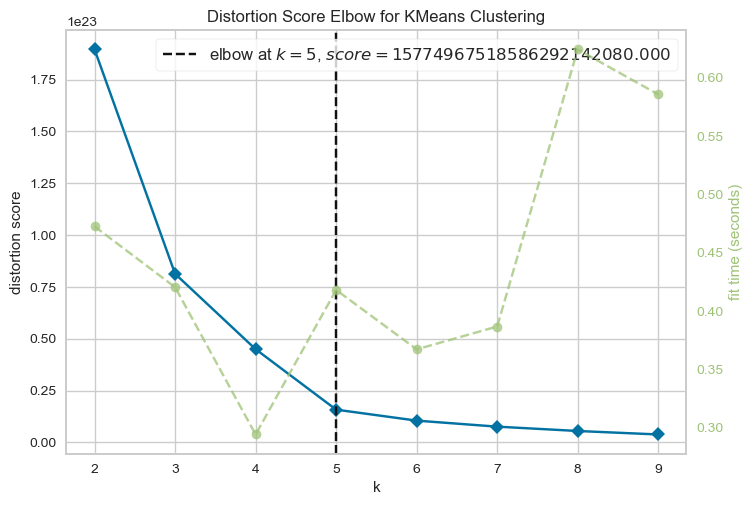

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: first_order_Mean_PET, Coefficient: -2.8944026395460987


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: glcm_Idmn_d_1_CT_c16, Coefficient: -1.81553559549209


...

Cluster 2: Most important feature: glcm_Idm_d_1_PET_b2, Coefficient: 1.27190352709865


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 3: Most important feature: shape_VoxelVolume, Coefficient: 3.0837148546622424


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 4: Most important feature: glcm_DifferenceAverage_d_1_CT_c16, Coefficient: -3.0776318969518517


In [22]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

# Standardization

In [23]:
# Do the standardization for X_fs_fi
scaler = StandardScaler() 
X_new_std= scaler.fit_transform(X_fs_fi)
X_new_std = pd.DataFrame(X_new_std,
                        columns=X_fs_fi.columns, 
                        index=X_fs_fi.index)

# Do the standardization for MAASTRO 
MAASTRO_new = X_MAASTRO[selected_features]
MAASTRO_new_std = scaler.transform(MAASTRO_new)
MAASTRO_new_std = pd.DataFrame(MAASTRO_new_std, 
                              columns=MAASTRO_new.columns, 
                              index=MAASTRO_new.index )

In [24]:
X_new

,first_order_Mean_PET,glcm_Idmn_d_1_CT_c16,glcm_Idm_d_1_PET_b2,shape_VoxelVolume,glcm_DifferenceAverage_d_1_CT_c16
0,7.489228,0.998252,0.826444,16214.0,0.340607
1,3.236345,0.996618,0.902339,2863.0,0.427467
2,4.223322,0.998604,0.917698,28989.0,0.231821
3,1.952779,0.996310,0.936960,3337.0,0.498842
4,3.774285,0.991932,0.899247,5018.0,0.764846
...,...,...,...,...,...
134,4.805702,0.998189,0.862698,8321.0,0.373733
135,4.700546,0.999244,0.931700,25403.0,0.112741
136,6.798946,0.997733,0.828841,15322.0,0.288076
137,4.828376,0.998547,0.916060,18450.0,0.249378


In [25]:
X_new_std

,first_order_Mean_PET,glcm_Idmn_d_1_CT_c16,glcm_Idm_d_1_PET_b2,shape_VoxelVolume,glcm_DifferenceAverage_d_1_CT_c16
0,0.571369,0.456785,-0.627496,-0.264205,-0.023025
1,-1.034766,-0.212800,0.623526,-0.663896,0.432669
2,-0.662026,0.600782,0.876691,0.118242,-0.593750
3,-1.519515,-0.338902,1.194208,-0.649706,0.807119
4,-0.831609,-2.132062,0.572556,-0.599382,2.202654
...,...,...,...,...,...
134,-0.442086,0.431157,-0.029908,-0.500499,0.150762
135,-0.481799,0.863170,1.107505,0.010887,-1.218478
136,0.310679,0.243992,-0.587992,-0.290909,-0.298617
137,-0.433523,0.577711,0.849697,-0.197266,-0.501642


In [26]:
MAASTRO_new

,first_order_Mean_PET,glcm_Idmn_d_1_CT_c16,glcm_Idm_d_1_PET_b2,shape_VoxelVolume,glcm_DifferenceAverage_d_1_CT_c16
0,8.620975,0.998319,0.833092,38115.0,0.178841
1,3.833351,0.998668,0.899189,17918.0,0.157211
2,6.182864,0.997797,0.849532,17475.0,0.239013
3,4.199987,0.995999,0.897972,12512.0,0.488008
4,4.872122,0.999010,0.911954,28361.0,0.200512
...,...,...,...,...,...
94,13.222061,0.998680,0.667635,12865.0,0.199974
95,5.751008,0.992922,0.867235,18413.0,0.622822
96,4.613887,0.998150,0.924211,35439.0,0.270780
97,6.385348,0.998636,0.854130,26221.0,0.254120


In [27]:
MAASTRO_new_std

,first_order_Mean_PET,glcm_Idmn_d_1_CT_c16,glcm_Idm_d_1_PET_b2,shape_VoxelVolume,glcm_DifferenceAverage_d_1_CT_c16
0,0.998783,0.484244,-0.517910,0.391448,-0.871695
1,-0.809302,0.627266,0.571607,-0.213192,-0.985175
2,0.078010,0.270288,-0.246926,-0.226455,-0.556017
3,-0.670839,-0.466015,0.551546,-0.375033,0.750283
4,-0.417002,0.767202,0.782012,0.099441,-0.758006
...,...,...,...,...,...
94,2.736419,0.632013,-3.245251,-0.364465,-0.760827
95,-0.085083,-1.726571,0.044885,-0.198373,1.457554
96,-0.514526,0.414778,0.984054,0.311336,-0.389359
97,0.154480,0.614016,-0.171138,0.035376,-0.476763


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 18:15:33,728] A new study created in memory with name: no-name-6a6ca922-ec50-4826-8246-0ed62404a368
python(40477) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5737051792828686
Fold 2 C-index: 0.4728682170542636
Fold 3 C-index: 0.5191489361702127


[I 2024-04-14 18:15:34,495] A new study created in memory with name: no-name-39fcb013-d3c6-4c89-bc75-7044e02f4456


Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.47639484978540775
[I 2024-04-14 18:15:34,489] Trial 0 finished with value: 0.495115451667676 and parameters: {}. Best is trial 0 with value: 0.495115451667676.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.495115451667676], datetime_start=datetime.datetime(2024, 4, 14, 18, 15, 33, 889161), datetime_complete=datetime.datetime(2024, 4, 14, 18, 15, 34, 488315), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.495115451667676


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24332275389789862
Fold 2 IBS: 0.2514873410671944
Fold 3 IBS: 0.23409272700098846
Fold 4 IBS: 0.30089388334777406
Fold 5 IBS: 0.2475066194043818
[I 2024-04-14 18:15:35,137] Trial 0 finished with value: 0.25546066494364744 and parameters: {}. Best is trial 0 with value: 0.25546066494364744.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.25546066494364744], datetime_start=datetime.datetime(2024, 4, 14, 18, 15, 34, 532835), datetime_complete=datetime.datetime(2024, 4, 14, 18, 15, 35, 136716), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.25546066494364744


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.495
train_ibs:  0.255


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.577
IBS score: 0.224


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 18:15:36,485] A new study created in memory with name: no-name-0f3f09c0-9a1f-4708-a9fa-7beca3a16ac1


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.4721115537848606
Fold 2 C-index: 0.6841085271317829
Fold 3 C-index: 0.8127659574468085
Fold 4 C-index: 0.44866920152091255


[I 2024-04-14 18:15:36,914] A new study created in memory with name: no-name-a7147364-ac5b-440b-a5be-f794a1574786


Fold 5 C-index: 0.4313304721030043
[I 2024-04-14 18:15:36,901] Trial 0 finished with value: 0.5697971423974737 and parameters: {}. Best is trial 0 with value: 0.5697971423974737.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5697971423974737], datetime_start=datetime.datetime(2024, 4, 14, 18, 15, 36, 528450), datetime_complete=datetime.datetime(2024, 4, 14, 18, 15, 36, 901694), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5697971423974737


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2472471001477872
Fold 2 IBS: 0.2320398805496421
Fold 3 IBS: 0.22898184600807375
Fold 4 IBS: 0.2419747820058122
Fold 5 IBS: 0.2293955971117708
[I 2024-04-14 18:15:37,633] Trial 0 finished with value: 0.2359278411646172 and parameters: {}. Best is trial 0 with value: 0.2359278411646172.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2359278411646172], datetime_start=datetime.datetime(2024, 4, 14, 18, 15, 37, 12319), datetime_complete=datetime.datetime(2024, 4, 14, 18, 15, 37, 632967), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2359278411646172


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.57
train_ibs:  0.236


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.568


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 18:15:38,176] A new study created in memory with name: no-name-15068597-1a3d-4e4d-ae10-67e96ea6e817


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5737051792828686
Fold 2 C-index: 0.7364341085271318
Fold 3 C-index: 0.7574468085106383


[I 2024-04-14 18:15:38,959] A new study created in memory with name: no-name-8fcf3478-ea93-44be-aecd-13702d1f37e8


Fold 4 C-index: 0.4296577946768061
Fold 5 C-index: 0.4892703862660944
[I 2024-04-14 18:15:38,931] Trial 0 finished with value: 0.5973028554527079 and parameters: {}. Best is trial 0 with value: 0.5973028554527079.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5973028554527079], datetime_start=datetime.datetime(2024, 4, 14, 18, 15, 38, 355558), datetime_complete=datetime.datetime(2024, 4, 14, 18, 15, 38, 931575), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5973028554527079


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24329563121324016
Fold 2 IBS: 0.22591013637662755
Fold 3 IBS: 0.213194004897606
Fold 4 IBS: 0.3010117734205778
Fold 5 IBS: 0.24721303194086788
[I 2024-04-14 18:15:39,830] Trial 0 finished with value: 0.24612491556978386 and parameters: {}. Best is trial 0 with value: 0.24612491556978386.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24612491556978386], datetime_start=datetime.datetime(2024, 4, 14, 18, 15, 39, 558), datetime_complete=datetime.datetime(2024, 4, 14, 18, 15, 39, 828342), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24612491556978386


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.597
train_ibs:  0.246


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.557


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.226


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 18:15:40,251] A new study created in memory with name: no-name-0d00145c-af83-4598-bd72-a6e415979687


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5737051792828686
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.4296577946768061
Fold 5 C-index: 0.48497854077253216
[I 2024-04-14 18:15:41,098] Trial 0 finished with value: 0.5948940987570961 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5948940987570961.
Fold 1 C-index: 0.5737051792828686
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7659574468085106
Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.48497854077253216
[I 2024-04-14 18:15:41,718] Trial 1 finished with value: 0.5942559074966364 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.5948940987570961.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7659574468085106
Fold 4 C-index: 0.4296577946768061
Fold 5 C-index: 0.48497854077253216
[I 2024-04-14 18:15:42,199] Trial 2 finished with value: 0.5743719452467765 and parameters: {'l1_ratio': 0.22692876841884

Fold 1 C-index: 0.5737051792828686
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.4892703862660944
[I 2024-04-14 18:15:51,349] Trial 24 finished with value: 0.5957377303311232 and parameters: {'l1_ratio': 0.7805647035680947}. Best is trial 6 with value: 0.5973028554527079.
Fold 1 C-index: 0.5737051792828686
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.4892703862660944
[I 2024-04-14 18:15:51,717] Trial 25 finished with value: 0.5957377303311232 and parameters: {'l1_ratio': 0.9368557715647121}. Best is trial 6 with value: 0.5973028554527079.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7914893617021277
Fold 4 C-index: 0.44866920152091255
Fold 5 C-index: 0.4206008583690987
[I 2024-04-14 18:15:51,946] Trial 26 finished with value: 0.5704050731136345 and parameters: {'l1_ratio': 0.0154237575512

Fold 5 C-index: 0.4892703862660944
[I 2024-04-14 18:16:01,589] Trial 47 finished with value: 0.5973028554527079 and parameters: {'l1_ratio': 0.9991045282580079}. Best is trial 6 with value: 0.5973028554527079.
Fold 1 C-index: 0.5737051792828686
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.4892703862660944
[I 2024-04-14 18:16:02,035] Trial 48 finished with value: 0.5957377303311232 and parameters: {'l1_ratio': 0.8342998569224302}. Best is trial 6 with value: 0.5973028554527079.
Fold 1 C-index: 0.5737051792828686
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.4892703862660944
[I 2024-04-14 18:16:02,787] Trial 49 finished with value: 0.5965129241295728 and parameters: {'l1_ratio': 0.9586049921503356}. Best is trial 6 with value: 0.5973028554527079.
Fold 1 C-index: 0.5737051792828686
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.

...

Fold 1 IBS: 0.24326217698145267
Fold 2 IBS: 0.2261608923408878
Fold 3 IBS: 0.2137724777336517
Fold 4 IBS: 0.30096899502413094
Fold 5 IBS: 0.24716330732444478
[I 2024-04-14 18:16:26,124] Trial 0 finished with value: 0.24626556988091358 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.24626556988091358.
Fold 1 IBS: 0.2431025424470448
Fold 2 IBS: 0.22716855078425424
Fold 3 IBS: 0.21600083349836738
Fold 4 IBS: 0.30084028581903527
Fold 5 IBS: 0.24703731045275445
[I 2024-04-14 18:16:26,599] Trial 1 finished with value: 0.24682990460029125 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.24626556988091358.
Fold 1 IBS: 0.24709071705881375
Fold 2 IBS: 0.22761361819251108
Fold 3 IBS: 0.21678316353837876
Fold 4 IBS: 0.30080566874370473
Fold 5 IBS: 0.2470271576053935
[I 2024-04-14 18:16:26,935] Trial 2 finished with value: 0.24786406502776037 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.2462655698809

Fold 1 IBS: 0.2431644114165381
Fold 2 IBS: 0.22690089959719137
Fold 3 IBS: 0.21545650809338077
Fold 4 IBS: 0.30086604131670064
Fold 5 IBS: 0.24706335882921152
[I 2024-04-14 18:16:44,133] Trial 25 finished with value: 0.2466902438506045 and parameters: {'l1_ratio': 0.3418550839715946}. Best is trial 22 with value: 0.23536989980498846.
Fold 1 IBS: 0.24708850125421283
Fold 2 IBS: 0.22770526376824127
Fold 3 IBS: 0.21694800181354265
Fold 4 IBS: 0.3008002900356089
Fold 5 IBS: 0.2470089443905797
[I 2024-04-14 18:16:44,590] Trial 26 finished with value: 0.24791020025243707 and parameters: {'l1_ratio': 0.2166744240378211}. Best is trial 22 with value: 0.23536989980498846.
Fold 1 IBS: 0.2471271536972626
Fold 2 IBS: 0.230104605085473
Fold 3 IBS: 0.22203056930412787
Fold 4 IBS: 0.24664214915362948
Fold 5 IBS: 0.2308982277020901
[I 2024-04-14 18:16:44,915] Trial 27 finished with value: 0.2353605409885166 and parameters: {'l1_ratio': 0.0607792618006927}. Best is trial 27 with value: 0.23536054098851

Fold 5 IBS: 0.23162368628793248
[I 2024-04-14 18:16:53,932] Trial 49 finished with value: 0.24533318604108184 and parameters: {'l1_ratio': 0.1397932584741205}. Best is trial 31 with value: 0.23531688201222475.
Fold 1 IBS: 0.24323352049153604
Fold 2 IBS: 0.22629293621814803
Fold 3 IBS: 0.21408303349864188
Fold 4 IBS: 0.30094148022814204
Fold 5 IBS: 0.2471527430573872
[I 2024-04-14 18:16:54,444] Trial 50 finished with value: 0.24634074269877101 and parameters: {'l1_ratio': 0.5938078108685914}. Best is trial 31 with value: 0.23531688201222475.
Fold 1 IBS: 0.2471454069266212
Fold 2 IBS: 0.23047111415394742
Fold 3 IBS: 0.223020231735527
Fold 4 IBS: 0.24581070830622972
Fold 5 IBS: 0.23067227044767855
[I 2024-04-14 18:16:54,678] Trial 51 finished with value: 0.2354239463140008 and parameters: {'l1_ratio': 0.04688889313970372}. Best is trial 31 with value: 0.23531688201222475.
Fold 1 IBS: 0.24710480225929507
Fold 2 IBS: 0.22955592860961577
Fold 3 IBS: 0.22069052945225953
Fold 4 IBS: 0.30064730

Fold 1 IBS: 0.2470869823893541
Fold 2 IBS: 0.2288819509939461
Fold 3 IBS: 0.219216335590534
Fold 4 IBS: 0.3007181941096713
Fold 5 IBS: 0.23150810510276237
[I 2024-04-14 18:17:02,382] Trial 74 finished with value: 0.24548231363725356 and parameters: {'l1_ratio': 0.12100151681304275}. Best is trial 62 with value: 0.23530996854270567.
Fold 1 IBS: 0.24716910308313947
Fold 2 IBS: 0.23088988002292954
Fold 3 IBS: 0.22427516908761208
Fold 4 IBS: 0.24483707969071503
Fold 5 IBS: 0.23038511472858464
[I 2024-04-14 18:17:02,567] Trial 75 finished with value: 0.2355112693225961 and parameters: {'l1_ratio': 0.03262581521259113}. Best is trial 62 with value: 0.23530996854270567.
Fold 1 IBS: 0.2470926570960417
Fold 2 IBS: 0.2291495596790503
Fold 3 IBS: 0.21978263116885605
Fold 4 IBS: 0.3007375691120569
Fold 5 IBS: 0.23139181692949728
[I 2024-04-14 18:17:02,833] Trial 76 finished with value: 0.24563084679710045 and parameters: {'l1_ratio': 0.10547176761438815}. Best is trial 62 with value: 0.23530996854

Fold 5 IBS: 0.2471849001621255
[I 2024-04-14 18:17:09,748] Trial 98 finished with value: 0.2462228667476935 and parameters: {'l1_ratio': 0.7667338152719219}. Best is trial 62 with value: 0.23530996854270567.
Fold 1 IBS: 0.24708661838971002
Fold 2 IBS: 0.22779696676264144
Fold 3 IBS: 0.21711436461731962
Fold 4 IBS: 0.3007945569257168
Fold 5 IBS: 0.24703009178257404
[I 2024-04-14 18:17:10,108] Trial 99 finished with value: 0.2479645196955924 and parameters: {'l1_ratio': 0.20695324617348163}. Best is trial 62 with value: 0.23530996854270567.


* Best trial for IBS: 
 FrozenTrial(number=62, state=TrialState.COMPLETE, values=[0.23530996854270567], datetime_start=datetime.datetime(2024, 4, 14, 18, 16, 58, 354101), datetime_complete=datetime.datetime(2024, 4, 14, 18, 16, 58, 569629), params={'l1_ratio': 0.07504174750370471}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=62, value=None

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.597
train_ibs:  0.235


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.980766121964777)

test_cindex : 0.557


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.07504174750370471)

test_ibs:  0.227


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [83]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 19:56:46,564] A new study created in memory with name: no-name-5e8edd8c-d4b9-4928-a4cb-9f15d609a6b6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.45617529880478086
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.4714828897338403
Fold 5 C-index: 0.4248927038626609
[I 2024-04-14 19:56:52,259] Trial 0 finished with value: 0.5628572014062007 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5628572014062007.
Fold 1 C-index: 0.5418326693227091
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.7276595744680852
Fold 4 C-index: 0.5247148288973384
Fold 5 C-index: 0.4034334763948498
[I 2024-04-14 19:56:56,174] Trial 1 finished with value: 0.5558071795840385 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717,

Fold 5 C-index: 0.4270386266094421
[I 2024-04-14 19:57:45,374] Trial 15 finished with value: 0.552727771906608 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 8, 'min_samples_leaf': 8, 'max_depth': 14, 'n_estimators': 87, 'oob_score': False, 'max_samples': 0.4747428535255964, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.11311294291919405, 'warm_start': False}. Best is trial 11 with value: 0.5672696291333873.
Fold 1 C-index: 0.43227091633466136
Fold 2 C-index: 0.6841085271317829
Fold 3 C-index: 0.5872340425531914
Fold 4 C-index: 0.4600760456273764
Fold 5 C-index: 0.45278969957081544
[I 2024-04-14 19:57:45,835] Trial 16 finished with value: 0.5232958462435655 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 2, 'min_samples_leaf': 16, 'max_depth': 20, 'n_estimators': 9, 'oob_score': False, 'max_samples': 0.8566300002821572, 'max_features': None, 'min_weight_fraction_leaf': 0.22594306843997863, 'warm_start': False}. Best is trial 11 with value: 0.567269629133

Fold 4 C-index: 0.5152091254752852
Fold 5 C-index: 0.44206008583690987
[I 2024-04-14 19:58:19,158] Trial 30 finished with value: 0.5882112756658862 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 19, 'min_samples_leaf': 8, 'max_depth': 12, 'n_estimators': 377, 'oob_score': True, 'max_samples': 0.7016345482998098, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.3337815339398299, 'warm_start': True}. Best is trial 27 with value: 0.6229040029903583.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7906976744186046
Fold 3 C-index: 0.8042553191489362
Fold 4 C-index: 0.5475285171102662
Fold 5 C-index: 0.5171673819742489
[I 2024-04-14 19:58:22,000] Trial 31 finished with value: 0.6275473084108893 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 18, 'min_samples_leaf': 10, 'max_depth': 12, 'n_estimators': 408, 'oob_score': True, 'max_samples': 0.9457876743464282, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.2910626446298337, 'warm_start': True}. Best i

...

Fold 1 IBS: 0.246386460438482
Fold 2 IBS: 0.23218899742898796
Fold 3 IBS: 0.22946758410602397
Fold 4 IBS: 0.24118772219117468
Fold 5 IBS: 0.2303071920630508
[I 2024-04-14 20:03:34,778] Trial 32 finished with value: 0.2359075912455439 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 8, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 175, 'oob_score': True, 'max_samples': 0.20444340416617043, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.19558060234973634}. Best is trial 27 with value: 0.23583547084615547.
Fold 1 IBS: 0.24684478929600995
Fold 2 IBS: 0.2322329224950302
Fold 3 IBS: 0.23005427140610996
Fold 4 IBS: 0.2412308304074783
Fold 5 IBS: 0.2301271605653773
[I 2024-04-14 20:03:38,813] Trial 33 finished with value: 0.23609799483400112 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 235, 'oob_score': True, 'max_samples': 0.23980153995474307, 'max_features': 'log2', 'min_weight_fraction_leaf

Fold 5 IBS: 0.22978676956550373
[I 2024-04-14 20:04:23,907] Trial 47 finished with value: 0.23575678560731528 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 160, 'oob_score': True, 'max_samples': 0.13434415907111946, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10612603041708193}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24757897353687755
Fold 2 IBS: 0.2320725752850252
Fold 3 IBS: 0.2299544780683508
Fold 4 IBS: 0.24154478404388094
Fold 5 IBS: 0.23016145399352744
[I 2024-04-14 20:04:25,305] Trial 48 finished with value: 0.2362624529855324 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 18, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 86, 'oob_score': True, 'max_samples': 0.12964207163685623, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10203918387448863}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24671151151924972
Fold 2 IBS: 0.2321

Fold 1 IBS: 0.24631928839139375
Fold 2 IBS: 0.23211332325251055
Fold 3 IBS: 0.22987340393724426
Fold 4 IBS: 0.24110794902474542
Fold 5 IBS: 0.2296571564179856
[I 2024-04-14 20:05:03,121] Trial 63 finished with value: 0.2358142242047759 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 150, 'oob_score': True, 'max_samples': 0.10056089265752739, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.026471209866795242}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24648722835656947
Fold 2 IBS: 0.23206092276817514
Fold 3 IBS: 0.22928811947466984
Fold 4 IBS: 0.24128731957110403
Fold 5 IBS: 0.22992351169818162
[I 2024-04-14 20:05:05,389] Trial 64 finished with value: 0.23580942037374003 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 104, 'oob_score': True, 'max_samples': 0.17392096150604247, 'max_features': 'sqrt', 'min_weight_fractio

Fold 5 IBS: 0.2942977294061655
[I 2024-04-14 20:05:38,844] Trial 78 finished with value: 0.24924737806174263 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 11, 'n_estimators': 171, 'oob_score': True, 'max_samples': 0.9147835512625551, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.13257772422273512}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24630596960013934
Fold 2 IBS: 0.23202892604980208
Fold 3 IBS: 0.23058361904315297
Fold 4 IBS: 0.24129573617042252
Fold 5 IBS: 0.2301768553877985
[I 2024-04-14 20:05:39,680] Trial 79 finished with value: 0.2360782212502631 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 12, 'n_estimators': 37, 'oob_score': True, 'max_samples': 0.2189744006895358, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17152888523323856}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24642825384745612
Fold 2 IBS: 0.2320

Fold 1 IBS: 0.24603980142682666
Fold 2 IBS: 0.23212293756683253
Fold 3 IBS: 0.22980177266109972
Fold 4 IBS: 0.24117019375096946
Fold 5 IBS: 0.23000323031974987
[I 2024-04-14 20:06:33,737] Trial 94 finished with value: 0.23582758714509566 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 186, 'oob_score': True, 'max_samples': 0.15211446012016716, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1336981908011637}. Best is trial 84 with value: 0.23572114547332967.
Fold 1 IBS: 0.24609144860992238
Fold 2 IBS: 0.23210462726436726
Fold 3 IBS: 0.23027168009436597
Fold 4 IBS: 0.24100241364516664
Fold 5 IBS: 0.2300638162943246
[I 2024-04-14 20:06:41,211] Trial 95 finished with value: 0.23590679718162938 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 13, 'max_depth': 3, 'n_estimators': 489, 'oob_score': True, 'max_samples': 0.12627955102410032, 'max_features': 'auto', 'min_weight_fraction

In [84]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [85]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.752
train_ibs:  0.236


#### Test

In [86]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [87]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=10, max_features='log2', max_leaf_nodes=9,
                     max_samples=0.8964566248930579, min_samples_leaf=4,
                     min_samples_split=15,
                     min_weight_fraction_leaf=0.0006661618506031593,
                     n_estimators=396, random_state=123, warm_start=True)

test_cindex:  0.555


RandomSurvivalForest(max_depth=3, max_features='auto', max_leaf_nodes=11,
                     max_samples=0.1369774849788948, min_samples_leaf=2,
                     min_samples_split=20,
                     min_weight_fraction_leaf=0.07082006896114468,
                     n_estimators=186, oob_score=True, random_state=123)

test_ibs:  0.23


In [88]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [89]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 20:06:56,141] A new study created in memory with name: no-name-d88d96c2-c0ae-430d-8b39-dcacb24171db


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.549800796812749
Fold 2 C-index: 0.751937984496124
Fold 3 C-index: 0.8170212765957446
Fold 4 C-index: 0.5399239543726235
Fold 5 C-index: 0.5150214592274678
[I 2024-04-14 20:06:57,352] Trial 0 finished with value: 0.6347410943009418 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6347410943009418.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 20:07:01,199] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}.

Fold 1 C-index: 0.4800796812749004
Fold 2 C-index: 0.6492248062015504
Fold 3 C-index: 0.7702127659574468
Fold 4 C-index: 0.4790874524714829
Fold 5 C-index: 0.49356223175965663
[I 2024-04-14 20:07:36,468] Trial 16 finished with value: 0.5744333875330074 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is trial 12 with value: 0.647495871630859.
Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.748062015503876
Fold 3 C-index: 0.7957446808510639
Fold 4 C-index: 0.4619771863117871
Fold 5 C-index: 0.4334763948497854
[I 2024-04-14 20:07:37,436] Trial 17 finished with value: 0.5954217766188403 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 12, 'n_estimators': 318, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.5537848605577689
Fold 2 C-index: 0.751937984496124
Fold 3 C-index: 0.825531914893617
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.5107296137339056
[I 2024-04-14 20:08:02,228] Trial 31 finished with value: 0.6348607530632793 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 6, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 408, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.6362712139580162, 'min_weight_fraction_leaf': 0.07324922325860758}. Best is trial 12 with value: 0.647495871630859.
Fold 1 C-index: 0.5418326693227091
Fold 2 C-index: 0.748062015503876
Fold 3 C-index: 0.8297872340425532
Fold 4 C-index: 0.5551330798479087
Fold 5 C-index: 0.5407725321888412
[I 2024-04-14 20:08:03,658] Trial 32 finished with value: 0.6431175061811777 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 411, 'oob_score': False, 'warm_start': True, 'max_features': 

...

Fold 1 IBS: 0.24585191913083518
Fold 2 IBS: 0.21935900802496117
Fold 3 IBS: 0.2177179462394464
Fold 4 IBS: 0.26804532463792957
Fold 5 IBS: 0.26098218839995074
[I 2024-04-14 20:11:10,021] Trial 30 finished with value: 0.24239127728662463 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 8, 'min_samples_leaf': 6, 'max_depth': 10, 'n_estimators': 206, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.7404711034775547, 'min_weight_fraction_leaf': 0.09250450122181014}. Best is trial 18 with value: 0.23501106916433287.
Fold 1 IBS: 0.24491843808017835
Fold 2 IBS: 0.22915765739458357
Fold 3 IBS: 0.22802682885942702
Fold 4 IBS: 0.24389472316933464
Fold 5 IBS: 0.23326883176753394
[I 2024-04-14 20:11:12,062] Trial 31 finished with value: 0.23585329585421153 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 9, 'n_estimators': 135, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.8485

Fold 1 IBS: 0.24349739676218238
Fold 2 IBS: 0.22674753972487366
Fold 3 IBS: 0.2270504795476157
Fold 4 IBS: 0.25192252178705427
Fold 5 IBS: 0.23646570277679851
[I 2024-04-14 20:11:37,299] Trial 45 finished with value: 0.2371367281197049 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 4, 'min_samples_leaf': 7, 'max_depth': 10, 'n_estimators': 155, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.8356264271114461, 'min_weight_fraction_leaf': 0.06918127503935843}. Best is trial 18 with value: 0.23501106916433287.
Fold 1 IBS: 0.2458181531795176
Fold 2 IBS: 0.2307162178976314
Fold 3 IBS: 0.22760611936037492
Fold 4 IBS: 0.24196116298069276
Fold 5 IBS: 0.23187637502027048
[I 2024-04-14 20:11:38,855] Trial 46 finished with value: 0.2355956056876974 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 6, 'min_samples_leaf': 1, 'max_depth': 15, 'n_estimators': 97, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.536827178448

Fold 1 IBS: 0.24607749071894738
Fold 2 IBS: 0.23034291129020223
Fold 3 IBS: 0.2266055146223415
Fold 4 IBS: 0.24231171566269188
Fold 5 IBS: 0.23312995946777368
[I 2024-04-14 20:12:07,312] Trial 60 finished with value: 0.2356935183523913 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 9, 'min_samples_leaf': 15, 'max_depth': 12, 'n_estimators': 144, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.6439578488770784, 'min_weight_fraction_leaf': 0.10555410651809251}. Best is trial 18 with value: 0.23501106916433287.
Fold 1 IBS: 0.24402814838754378
Fold 2 IBS: 0.22898774358789506
Fold 3 IBS: 0.22792987387368538
Fold 4 IBS: 0.24360602952360208
Fold 5 IBS: 0.23349991586376706
[I 2024-04-14 20:12:08,353] Trial 61 finished with value: 0.23561034224729865 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 5, 'min_samples_leaf': 17, 'max_depth': 11, 'n_estimators': 55, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.7969059

Fold 2 IBS: 0.22220512097555742
Fold 3 IBS: 0.22554962272442522
Fold 4 IBS: 0.24912643073309823
Fold 5 IBS: 0.23483850717245008
[I 2024-04-14 20:12:30,494] Trial 75 finished with value: 0.2338608967500757 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 12, 'min_samples_leaf': 13, 'max_depth': 13, 'n_estimators': 9, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.9275535853074112, 'min_weight_fraction_leaf': 0.03504772959602757}. Best is trial 73 with value: 0.23334497220484735.
Fold 1 IBS: 0.2348048337790492
Fold 2 IBS: 0.2226566882120235
Fold 3 IBS: 0.22060842405137757
Fold 4 IBS: 0.24732232021546882
Fold 5 IBS: 0.24246979635281019
[I 2024-04-14 20:12:30,743] Trial 76 finished with value: 0.2335724125221459 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 12, 'min_samples_leaf': 13, 'max_depth': 13, 'n_estimators': 4, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.9327134729271581, 'min_weight_fraction_leaf'

Fold 1 IBS: 0.2414339740381181
Fold 2 IBS: 0.2255512362168371
Fold 3 IBS: 0.227260207360291
Fold 4 IBS: 0.2447103749081887
Fold 5 IBS: 0.23305941811933215
[I 2024-04-14 20:12:35,804] Trial 90 finished with value: 0.2344030421285534 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 13, 'max_depth': 19, 'n_estimators': 17, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.8904494281001407, 'min_weight_fraction_leaf': 0.011432177298798057}. Best is trial 84 with value: 0.23329632785550566.
Fold 1 IBS: 0.23941115677593233
Fold 2 IBS: 0.2208531537811862
Fold 3 IBS: 0.22392854032067003
Fold 4 IBS: 0.24881824527345425
Fold 5 IBS: 0.23516413953943247
[I 2024-04-14 20:12:36,159] Trial 91 finished with value: 0.23363504713813504 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 17, 'n_estimators': 12, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.9543280

In [90]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [91]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.656
train_ibs:  0.233


#### Test

In [92]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [93]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=11, max_features=None, max_leaf_nodes=12,
                   max_samples=0.39920351573122975, min_samples_leaf=4,
                   min_samples_split=13,
                   min_weight_fraction_leaf=0.0217922681887993,
                   n_estimators=330, random_state=123, warm_start=True)

C-index score: 0.547


ExtraSurvivalTrees(max_depth=17, max_features=0.1, max_leaf_nodes=12,
                   max_samples=0.9247567647171473, min_samples_leaf=13,
                   min_samples_split=10,
                   min_weight_fraction_leaf=0.016317006565541674,
                   n_estimators=12, random_state=123, warm_start=True)

IBS: 0.227


In [94]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [95]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 20:12:48,310] A new study created in memory with name: no-name-01444dc8-5b56-41c1-947f-ed2357a7d68a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 20:13:17,182] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 20:13:32,876] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 20:19:44,457] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.5143227233076013.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 20:20:36,341] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 20:26:34,843] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.5143227233076013.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 20:27:24,462] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 21:07:12,016] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 21:07:15,157] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 21:09:22,612] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-14 21:09:36,420] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 21:11:16,071] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 21:11:30,365] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 21:13:10,934] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 21:13:28,645] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 21:15:51,575] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 21:15:52,486] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [96]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [97]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.514
train_ibs:  0.236


#### Test

In [98]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [99]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.516


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [100]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [101]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 21:18:03,795] A new study created in memory with name: no-name-eeb8e15d-e433-420f-877b-1fe67be7813c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4940239043824701
Fold 2 C-index: 0.7209302325581395
Fold 3 C-index: 0.8
Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.44206008583690987
[I 2024-04-14 21:18:04,708] Trial 0 finished with value: 0.5780948597646293 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5780948597646293.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7957446808510639
Fold 4 C-index: 0.42585551330798477
Fold 5 C-index: 0.43776824034334766
[I 2024-04-14 21:18:14,116] Trial 1 finished with value: 0.5701268756956861 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5780948597646293.
Fold 1 C-index: 0.4940239043824701
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.8212765957446808
Fold 4 C-index:

Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.41064638783269963
Fold 5 C-index: 0.4721030042918455
[I 2024-04-14 21:19:05,482] Trial 19 finished with value: 0.5662924289222435 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.7254192287154788, 'n_estimators': 40, 'learning_rate': 0.018369564224062086}. Best is trial 3 with value: 0.5930955976652571.
Fold 1 C-index: 0.5139442231075697
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.8085106382978723
Fold 4 C-index: 0.4372623574144487
Fold 5 C-index: 0.4291845493562232
[I 2024-04-14 21:19:06,185] Trial 20 finished with value: 0.5827415939453002 and parameters: {'subsample': 0.4455850328103009, 'dropout_rate': 0.19277125655860103, 'n_estimators': 56, 'learning_rate': 0.034329779270997215}. Best is trial 3 with value: 0.5930955976652571.
Fold 1 C-index: 0.5418326693227091
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.8085106382978723
Fold 4 C-index: 0.44866920152091255
Fo

Fold 1 C-index: 0.5099601593625498
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.8042553191489362
Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.44635193133047213
[I 2024-04-14 21:19:52,940] Trial 38 finished with value: 0.5845419312860443 and parameters: {'subsample': 0.31412726738627755, 'dropout_rate': 0.5078782179550642, 'n_estimators': 338, 'learning_rate': 0.07288612365177065}. Best is trial 25 with value: 0.5946060478630023.
Fold 1 C-index: 0.5298804780876494
Fold 2 C-index: 0.7325581395348837
Fold 3 C-index: 0.8085106382978723
Fold 4 C-index: 0.44866920152091255
Fold 5 C-index: 0.44635193133047213
[I 2024-04-14 21:19:55,619] Trial 39 finished with value: 0.5931940777543581 and parameters: {'subsample': 0.3137324838600557, 'dropout_rate': 0.4536445779706528, 'n_estimators': 234, 'learning_rate': 0.06655181112053613}. Best is trial 25 with value: 0.5946060478630023.
Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.686046511627907
Fold 3 C-index: 0.81702127659574

...

Fold 3 IBS: 0.1913490296129142
Fold 4 IBS: 0.32328504983708867
Fold 5 IBS: 0.2612185191808462
[I 2024-04-14 21:22:16,944] Trial 19 finished with value: 0.2553752553694658 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.9949834936920623, 'n_estimators': 134, 'learning_rate': 0.036212385990032875}. Best is trial 11 with value: 0.23554723053691395.
Fold 1 IBS: 0.24750929044371336
Fold 2 IBS: 0.22423648049539224
Fold 3 IBS: 0.21530950489438477
Fold 4 IBS: 0.25871990633955894
Fold 5 IBS: 0.23012093885085355
[I 2024-04-14 21:22:17,656] Trial 20 finished with value: 0.2351792242047806 and parameters: {'subsample': 0.9139336698304192, 'dropout_rate': 0.6485024664008028, 'n_estimators': 61, 'learning_rate': 0.017331004877487094}. Best is trial 20 with value: 0.2351792242047806.
Fold 1 IBS: 0.24729492080780385
Fold 2 IBS: 0.22555328066843855
Fold 3 IBS: 0.2170104898509438
Fold 4 IBS: 0.25577600054521343
Fold 5 IBS: 0.22973343479708494
[I 2024-04-14 21:22:18,302] Trial 21 fini

Fold 3 IBS: 0.21347516985731166
Fold 4 IBS: 0.27167567836172196
Fold 5 IBS: 0.23372861218394927
[I 2024-04-14 21:22:38,911] Trial 38 finished with value: 0.23776772796917434 and parameters: {'subsample': 0.7738637241845859, 'dropout_rate': 0.13272164755980653, 'n_estimators': 32, 'learning_rate': 0.06996019623868041}. Best is trial 21 with value: 0.23507362533389692.
Fold 1 IBS: 0.2473222462018682
Fold 2 IBS: 0.2245420896965624
Fold 3 IBS: 0.2194845954563623
Fold 4 IBS: 0.25778804390326754
Fold 5 IBS: 0.2307616764211467
[I 2024-04-14 21:22:39,500] Trial 39 finished with value: 0.23597973033584144 and parameters: {'subsample': 0.68189514993072, 'dropout_rate': 0.8200360262998327, 'n_estimators': 68, 'learning_rate': 0.01553125553441833}. Best is trial 21 with value: 0.23507362533389692.
Fold 1 IBS: 0.3072586577398309
Fold 2 IBS: 0.22591159389927787
Fold 3 IBS: 0.18786259313867112
Fold 4 IBS: 0.3260077997830813
Fold 5 IBS: 0.27779980795796805
[I 2024-04-14 21:22:40,480] Trial 40 finished

Fold 1 IBS: 0.24708533765207924
Fold 2 IBS: 0.22829443917884426
Fold 3 IBS: 0.22163872590817355
Fold 4 IBS: 0.24910023314690585
Fold 5 IBS: 0.22951581968171167
[I 2024-04-14 21:22:51,026] Trial 58 finished with value: 0.23512691111354292 and parameters: {'subsample': 0.9911018626676683, 'dropout_rate': 0.9571073021399931, 'n_estimators': 10, 'learning_rate': 0.04787334822236191}. Best is trial 54 with value: 0.23484201730771978.
Fold 1 IBS: 0.24600474317997298
Fold 2 IBS: 0.22943455652249042
Fold 3 IBS: 0.22361396800805372
Fold 4 IBS: 0.25229838655319053
Fold 5 IBS: 0.23119788137052277
[I 2024-04-14 21:22:51,328] Trial 59 finished with value: 0.2365099071268461 and parameters: {'subsample': 0.14522006252948272, 'dropout_rate': 0.9439625484392694, 'n_estimators': 16, 'learning_rate': 0.043010422649828496}. Best is trial 54 with value: 0.23484201730771978.
Fold 1 IBS: 0.2599656263911431
Fold 2 IBS: 0.21265717501649414
Fold 3 IBS: 0.19231158605807472
Fold 4 IBS: 0.3015167135709189
Fold 5 

Fold 2 IBS: 0.22482220457189592
Fold 3 IBS: 0.21517909498640722
Fold 4 IBS: 0.256850341890402
Fold 5 IBS: 0.22977448229042796
[I 2024-04-14 21:23:16,880] Trial 77 finished with value: 0.2348017465115194 and parameters: {'subsample': 0.9984053371332962, 'dropout_rate': 0.9121444694709047, 'n_estimators': 19, 'learning_rate': 0.04960207295118081}. Best is trial 63 with value: 0.23479295162806363.
Fold 1 IBS: 0.2684435142013744
Fold 2 IBS: 0.21234374013765425
Fold 3 IBS: 0.1907260513911944
Fold 4 IBS: 0.3118074480632625
Fold 5 IBS: 0.24731530789809034
[I 2024-04-14 21:23:17,462] Trial 78 finished with value: 0.2461272123383152 and parameters: {'subsample': 0.9309289111661625, 'dropout_rate': 0.9118906052959331, 'n_estimators': 61, 'learning_rate': 0.06589770178231695}. Best is trial 63 with value: 0.23479295162806363.
Fold 1 IBS: 0.2629210672890344
Fold 2 IBS: 0.21267095075547113
Fold 3 IBS: 0.19493449042809008
Fold 4 IBS: 0.30546912191082404
Fold 5 IBS: 0.24167111033629202
[I 2024-04-14 

Fold 3 IBS: 0.199632908573828
Fold 4 IBS: 0.3064686621920775
Fold 5 IBS: 0.2414428730765451
[I 2024-04-14 21:23:33,047] Trial 96 finished with value: 0.2443842809681361 and parameters: {'subsample': 0.58224961761559, 'dropout_rate': 0.7790586642461239, 'n_estimators': 88, 'learning_rate': 0.044708644692763026}. Best is trial 63 with value: 0.23479295162806363.
Fold 1 IBS: 0.2485246911041183
Fold 2 IBS: 0.22077508490277764
Fold 3 IBS: 0.20747035089820653
Fold 4 IBS: 0.26807014334283785
Fold 5 IBS: 0.23041989022808362
[I 2024-04-14 21:23:33,523] Trial 97 finished with value: 0.2350520320952048 and parameters: {'subsample': 0.9998766182675201, 'dropout_rate': 0.8563868238987072, 'n_estimators': 32, 'learning_rate': 0.04844622585847104}. Best is trial 63 with value: 0.23479295162806363.
Fold 1 IBS: 0.24721936154232813
Fold 2 IBS: 0.23170937368735003
Fold 3 IBS: 0.22863691452614152
Fold 4 IBS: 0.24250006626236087
Fold 5 IBS: 0.22940020506070172
[I 2024-04-14 21:23:33,793] Trial 98 finished 

In [102]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [103]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.597
train_ibs:  0.235


#### Test

In [104]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [105]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.1385535608576704,
                                              learning_rate=0.04946054535646146,
                                              n_estimators=97, random_state=123,
                                              subsample=0.414634446825686)

C-index score: 0.563


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8592741809894265,
                                              learning_rate=0.051617665954568084,
                                              n_estimators=19, random_state=123,
                                              subsample=0.9969642974836825)

IBS: 0.226


In [106]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [107]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.752,1.0
ExtraSurvivalTrees,0.656,2.0
CoxLasso,0.597,4.0
CoxElastic,0.597,4.0
ComponentwiseGradientBoosting,0.597,4.0
CoxRidge,0.570,6.0
GradientBoosting,0.514,7.0
CoxPH,0.495,8.0


In [108]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.233,1.0
CoxElastic,0.235,2.5
ComponentwiseGradientBoosting,0.235,2.5
CoxRidge,0.236,5.0
Randomsurvivalforest,0.236,5.0
GradientBoosting,0.236,5.0
CoxLasso,0.246,7.0
CoxPH,0.255,8.0


In [109]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxPH,0.577,1.0
CoxRidge,0.568,2.0
ComponentwiseGradientBoosting,0.563,3.0
CoxLasso,0.557,4.5
CoxElastic,0.557,4.5
Randomsurvivalforest,0.555,6.0
ExtraSurvivalTrees,0.547,7.0
GradientBoosting,0.516,8.0


In [110]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxPH,0.224,1.0
CoxLasso,0.226,2.5
ComponentwiseGradientBoosting,0.226,2.5
CoxElastic,0.227,4.5
ExtraSurvivalTrees,0.227,4.5
CoxRidge,0.229,6.5
GradientBoosting,0.229,6.5
Randomsurvivalforest,0.230,8.0


In [113]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/dfs/standard/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file namess
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_dfs_standard_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [114]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
